In [1]:
import rasterio
from spectral import envi
import numpy as np

In [3]:
def pstretch(arr, lo=2, hi=98):
    a = arr.astype(np.float32)
    v = a[np.isfinite(a) & (a > 0)]
    if v.size == 0:
        return np.zeros_like(a)
    lo_v, hi_v = np.percentile(v, [lo, hi])
    return np.clip((a - lo_v) / (hi_v - lo_v + 1e-9), 0, 1)

def load_sentinel(bands):
    loaded_bands = []

    for key in ("B", "G", "R", "NIR", "RE"):
        with rasterio.open(bands[key]) as src:
            loaded_bands.append(src.read(1))

    return np.stack([b for b in loaded_bands], axis=-1)

scene_15_sentinel_bands = {
    "R": "sentinel_10m_cropped/box_2/B04.tif",
    "G": "sentinel_10m_cropped/box_2/B03.tif",
    "B": "sentinel_10m_cropped/box_2/B02.tif",
    "NIR": "sentinel_10m_cropped/box_2/B08.tif",
    "RE": "sentinel_10m_cropped/box_2/B05_10m.tif",
}

In [4]:
scene_15_sentinel = load_sentinel(scene_15_sentinel_bands)
scene_15_sentinel.shape

(215, 459, 5)

In [5]:
scene_15_hyperspectral = envi.open("data/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr")

band_names = ["B02", "B03", "B04", "B08"]
band_wavelengths = [490, 560, 665, 842]

idx_in_hyperspectral = []

wavelengths = np.array(scene_15_hyperspectral.metadata['wavelength'], dtype=float)

for bwl in band_wavelengths:
    nearest_idx = int(np.argmin(np.abs(wavelengths - bwl)))
    idx_in_hyperspectral.append(nearest_idx)

for name, wl, idx in zip(band_names, band_wavelengths, idx_in_hyperspectral):
    print(f"Found {name} of length {wl} at {idx}")



Found B02 of length 490 at 24
Found B03 of length 560 at 46
Found B04 of length 665 at 78
Found B08 of length 842 at 134


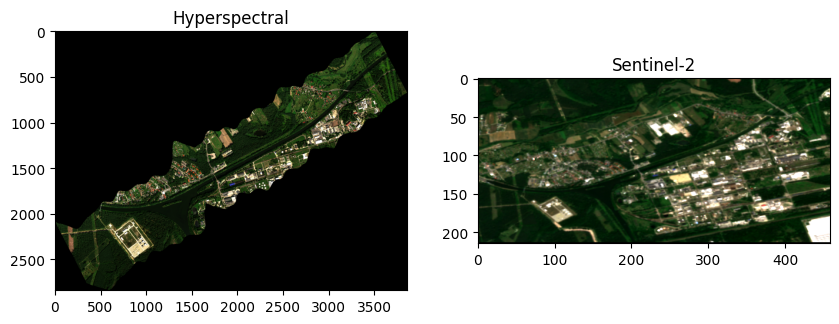

In [6]:
import matplotlib.pyplot as plt

hs_rgb = scene_15_hyperspectral[:, :, [79, 46, 24]] 

sentinel_rgb = scene_15_sentinel[:, :, [2, 1, 0]]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pstretch(hs_rgb))
ax[0].set_title("Hyperspectral")
ax[1].imshow(pstretch(sentinel_rgb))
ax[1].set_title("Sentinel-2")
plt.show()

In [7]:
src_sent = rasterio.open(scene_15_sentinel_bands["R"])
print("Sentinel Bounds:", src_sent.bounds)
print("Sentinel CRS:", src_sent.crs)

src_hyper = envi.open("data/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr")
print("Hyper CRS:", src_hyper.metadata.get("map info"))

Sentinel Bounds: BoundingBox(left=18.241826996827825, bottom=50.34312015188819, right=18.296328329697992, top=50.36864909865744)
Sentinel CRS: EPSG:4326
Hyper CRS: ['Transverse_Mercator', '1', '1', '6517216.000', '5581457.000', '1.0000000', '1.0000000', 'ETRS 1989', 'units=Meter']


In [8]:
from rasterio.warp import reproject, Resampling
import numpy as np
from affine import Affine

src_crs = 'EPSG:2177'
dst_crs = 'EPSG:4326'

target_idx = idx_in_hyperspectral
hyper_bands = scene_15_hyperspectral.read_bands(target_idx)

hyper_bands_reshaped = np.moveaxis(hyper_bands, -1, 0)

sentinel_h, sentinel_w = scene_15_sentinel.shape[:2]
hyper_aligned = np.zeros((4, sentinel_h, sentinel_w), dtype=np.float32)

hyper_transform = Affine.translation(6517216.000, 5581457.000) * Affine.scale(1.0, -1.0)

with rasterio.open(scene_15_sentinel_bands["R"]) as ref:
    reproject(
        source=hyper_bands_reshaped,
        destination=hyper_aligned,
        src_transform=hyper_transform,
        src_crs=src_crs,
        dst_transform=ref.transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

hyper_final = np.moveaxis(hyper_aligned, 0, -1)

In [9]:
print(hyper_final.shape)
print(scene_15_sentinel.shape)

(215, 459, 4)
(215, 459, 5)


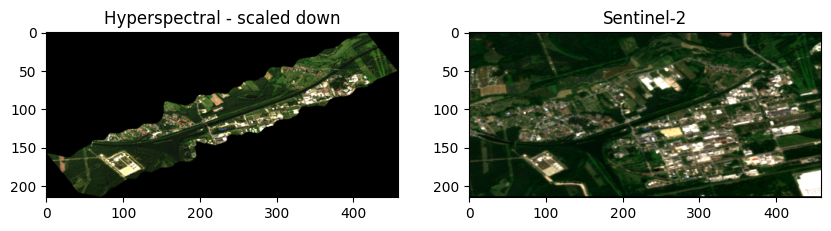

In [10]:
import matplotlib.pyplot as plt

hs_rgb = hyper_final[:, :, [2, 1, 0]] 
sentinel_rgb = scene_15_sentinel[:, :, [2,1,0]]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pstretch(hs_rgb))
ax[0].set_title("Hyperspectral - scaled down")
ax[1].imshow(pstretch(sentinel_rgb))
ax[1].set_title("Sentinel-2")
plt.show()

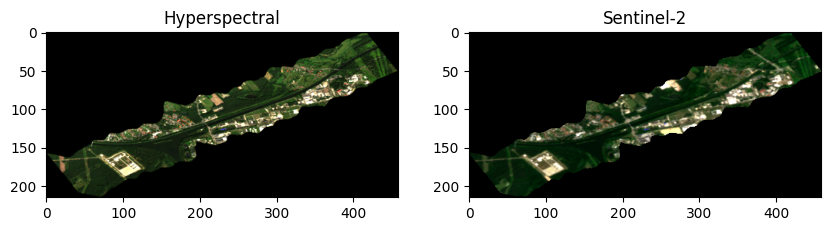

In [11]:
import numpy as np

mask_threshold = 0.00045

sentinel_masked = scene_15_sentinel.copy()

final_mask = np.sum(np.abs(hyper_final), axis=-1) >= mask_threshold
sentinel_masked[~final_mask] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pstretch(hyper_final[:, :, [2, 1, 0]]))
ax[0].set_title("Hyperspectral")

ax[1].imshow(pstretch(sentinel_masked[:, :, [2,1,0]]))
ax[1].set_title("Sentinel-2")

plt.show()

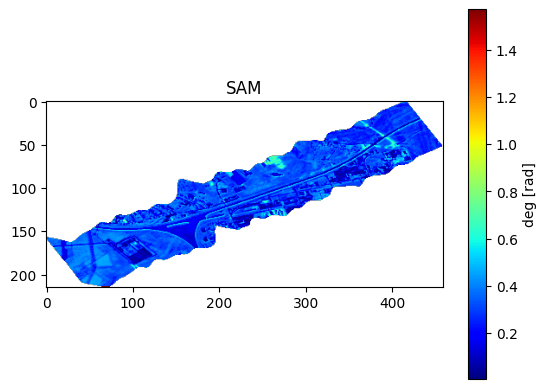

In [12]:
import numpy as np

def calculate_sam(img1, img2, mask):
    dot_product = np.sum(img1 * img2, axis=-1)
    
    norm1 = np.linalg.norm(img1, axis=-1)
    norm2 = np.linalg.norm(img2, axis=-1)
    
    cos_theta = dot_product / (norm1 * norm2 + 1e-9)
    sam = np.arccos(np.clip(cos_theta, -1, 1))
    
    sam[~mask] = np.nan
    return sam

final_mask = np.sum(np.abs(hyper_final), axis=-1) >= mask_threshold

sam_map = calculate_sam(sentinel_masked[:, :, [0, 1, 2, 3]], hyper_final, final_mask)

plt.imshow(sam_map, cmap='jet')
plt.colorbar(label='deg [rad]')
plt.title("SAM")
plt.show()

In [13]:
from scipy import stats
import pandas as pd

band_names = ['Blue', 'Green', 'Red', 'NIR']
results = []

for i in range(4):
    x = scene_15_sentinel[final_mask, i] / 10000.0
    y = hyper_final[final_mask, i]
    
    clean = np.isfinite(x) & np.isfinite(y)
    x_f, y_f = x[clean], y[clean]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_f, y_f)
    
    results.append({
        'Band': band_names[i],
        'Slope (a)': round(slope, 4),
        'Intercept (b)': round(intercept, 4),
        'R2': round(r_value**2, 4)
    })

df_results = pd.DataFrame(results)
print(df_results)

    Band  Slope (a)  Intercept (b)      R2
0   Blue     0.6697        -0.0685  0.6390
1  Green     0.8382        -0.0895  0.5652
2    Red     0.7668        -0.0753  0.5905
3    NIR     0.8138        -0.0773  0.5363


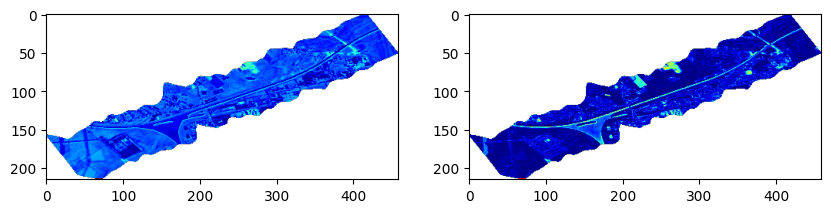

In [14]:
import matplotlib.pyplot as plt

slopes = [0.6697, 0.8382, 0.7668, 0.8138] 
intercepts = [-0.0685, -0.0895, -0.0753, -0.0773]

s2_rescaled = (scene_15_sentinel / 10000.0)[:, :, [0, 1, 2, 3]]
s2_calibrated = np.zeros_like(s2_rescaled)

for i in range(4):
    s2_calibrated[:,:,i] = s2_rescaled[:,:,i] * slopes[i] + intercepts[i]

s2_calibrated = np.clip(s2_calibrated, 1e-5, 1.0)
s2_sam_map = calculate_sam(s2_calibrated, hyper_final, final_mask)

fig,ax=plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(sam_map, cmap="jet")
ax[1].imshow(s2_sam_map, cmap="jet")
plt.show()